# Notebook 04: Statistical Analysis

**Data Overview:** Rows: 12,295 | Columns: 22

**Goal:** This notebook performs a comprehensive statistical analysis, including univariate and bivariate profiling of all features against `Accident_severity`, to identify key patterns and relationships.

### 1. Importing Libraries
This cell imports necessary libraries for data manipulation, analysis, and visualization.

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import mode

### 2. Loading the Dataset
This cell loads the `cleaned_dataset.csv` file into a pandas DataFrame and displays the first few rows to inspect its structure.

In [2]:
df = pd.read_csv("cleaned_dataset.csv")

df.head()

,Accident_severity,Number_of_casualties,Time,Day_of_week,Area_accident_occured,Types_of_Junction,Road_allignment,Lanes_or_Medians,Weather_conditions,Light_conditions,...,Vehicle_movement,Cause_of_accident,Age_band_of_driver,Driving_experience,Sex_of_driver,Type_of_vehicle,Hour,Time_period,severity_score,is_weekend
0,slight injury,2,1900-01-01 17:02:00,monday,residential areas,no junction,tangent road with flat terrain,two-way (divided with broken lines road marking),normal,daylight,...,going straight,moving backward,18-30,1-2yr,male,automobile,17,afternoon,1,False
1,slight injury,2,1900-01-01 17:02:00,monday,office areas,no junction,tangent road with flat terrain,undivided two way,normal,daylight,...,going straight,overtaking,31-50,above 10yr,male,public (> 45 seats),17,afternoon,1,False
2,serious injury,2,1900-01-01 17:02:00,monday,recreational areas,no junction,tangent road with flat terrain,other,normal,daylight,...,going straight,changing lane to the left,18-30,1-2yr,male,lorry (41?100q),17,afternoon,2,False
3,slight injury,2,1900-01-01 01:06:00,sunday,office areas,y shape,tangent road with mild grade and flat terrain,other,normal,darkness - lights lit,...,going straight,changing lane to the right,18-30,5-10yr,male,public (> 45 seats),1,night,1,True
4,slight injury,2,1900-01-01 01:06:00,sunday,industrial areas,y shape,tangent road with flat terrain,other,normal,darkness - lights lit,...,going straight,overtaking,18-30,2-5yr,male,automobile,1,night,1,True


### 3. Cleaning Column Names
This cell cleans the DataFrame's column names by stripping whitespace, replacing spaces with underscores, and converting them to lowercase for easier access and consistency.

In [23]:
df = pd.read_csv("cleaned_dataset.csv")

df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ','_')
    .str.lower()
)

df.head()

,accident_severity,number_of_casualties,time,day_of_week,area_accident_occured,types_of_junction,road_allignment,lanes_or_medians,weather_conditions,light_conditions,...,vehicle_movement,cause_of_accident,age_band_of_driver,driving_experience,sex_of_driver,type_of_vehicle,hour,time_period,severity_score,is_weekend
0,slight injury,2,1900-01-01 17:02:00,monday,residential areas,no junction,tangent road with flat terrain,two-way (divided with broken lines road marking),normal,daylight,...,going straight,moving backward,18-30,1-2yr,male,automobile,17,afternoon,1,False
1,slight injury,2,1900-01-01 17:02:00,monday,office areas,no junction,tangent road with flat terrain,undivided two way,normal,daylight,...,going straight,overtaking,31-50,above 10yr,male,public (> 45 seats),17,afternoon,1,False
2,serious injury,2,1900-01-01 17:02:00,monday,recreational areas,no junction,tangent road with flat terrain,other,normal,daylight,...,going straight,changing lane to the left,18-30,1-2yr,male,lorry (41?100q),17,afternoon,2,False
3,slight injury,2,1900-01-01 01:06:00,sunday,office areas,y shape,tangent road with mild grade and flat terrain,other,normal,darkness - lights lit,...,going straight,changing lane to the right,18-30,5-10yr,male,public (> 45 seats),1,night,1,True
4,slight injury,2,1900-01-01 01:06:00,sunday,industrial areas,y shape,tangent road with flat terrain,other,normal,darkness - lights lit,...,going straight,overtaking,18-30,2-5yr,male,automobile,1,night,1,True


### 4. Defining Numerical Columns
This cell defines a list of columns that contain numerical data, which will be used for further statistical analysis.

In [24]:
numerical_cols = [
    'number_of_casualties',
    'hour'
]

### 5. Calculating Central Tendency Measures
This cell calculates the mean, median, and mode for the identified numerical columns to understand their central values.

In [25]:
stats_table = pd.DataFrame({

'Mean':
df[numerical_cols].mean(),

'Median':
df[numerical_cols].median(),

'Mode':
df[numerical_cols].mode().iloc[0]

})

stats_table

,Mean,Median,Mode
number_of_casualties,1.548190,1.0,1
hour,13.833591,15.0,17


### 6. Calculating Measures of Dispersion
This cell computes various measures of dispersion, including variance, standard deviation, minimum, maximum, and range, to assess the spread of the numerical data.

In [26]:
dispersion = pd.DataFrame({

'Variance':
df[numerical_cols].var(),

'Std_Dev':
df[numerical_cols].std(),

'Min':
df[numerical_cols].min(),

'Max':
df[numerical_cols].max(),

'Range':
df[numerical_cols].max()-df[numerical_cols].min()

})

dispersion

,Variance,Std_Dev,Min,Max,Range
number_of_casualties,1.013112,1.006535,1,8,7
hour,27.073656,5.203235,0,23,23


### 7. Analyzing Quartiles and Interquartile Range (IQR)
This cell calculates the first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR) for numerical columns to identify data distribution and potential outliers.

In [27]:
for col in numerical_cols:

    Q1 = df[col].quantile(.25)

    Q3 = df[col].quantile(.75)

    IQR = Q3-Q1

    print(col)

    print("Q1:",Q1)

    print("Q3:",Q3)

    print("IQR:",IQR)

    print("-"*50)

number_of_casualties
Q1: 1.0
Q3: 2.0
IQR: 1.0
--------------------------------------------------
hour
Q1: 10.0
Q3: 18.0
IQR: 8.0
--------------------------------------------------


### 8. Checking for Skewness
This cell calculates the skewness for each numerical column to determine the asymmetry of their probability distribution.

In [30]:
for col in numerical_cols:

    print(
        col,
        skew(df[col])
    )

number_of_casualties 2.342765557180206
hour -0.5051082348378638


### 9. Aggregating Casualties by Accident Severity
This cell groups the data by `accident_severity` and calculates the mean and median `number_of_casualties` for each severity level.

In [31]:
df.groupby(
'accident_severity'
)['number_of_casualties'].agg(

['mean','median']

)

,mean,median
accident_severity,,
fatal injury,2.341772,2.0
serious injury,1.534254,1.0
slight injury,1.538462,1.0


### 10. Determining Mode of Casualties by Accident Severity
This cell identifies the mode (most frequent value) of `number_of_casualties` for each `accident_severity` category.

In [32]:
for sev in df['accident_severity'].unique():

    subset = df[
df['accident_severity']==sev
]['number_of_casualties']

    print(

    sev,

    subset.mode().iloc[0]

    )

slight injury 1
serious injury 1
fatal injury 1


### 11. Visualizing Average Casualties by Hour
This cell generates a line plot showing the average `number_of_casualties` throughout different hours of the day.

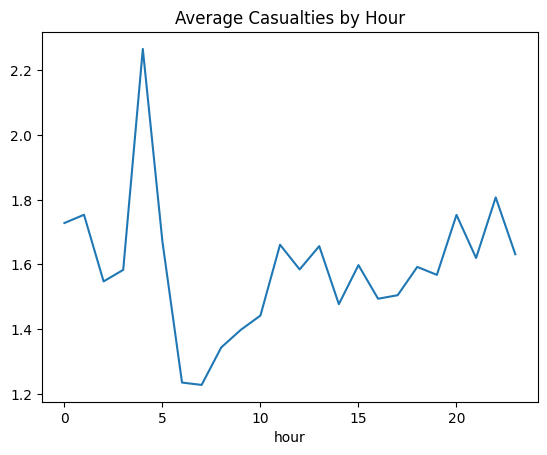

In [33]:
df.groupby(
'hour'
)['number_of_casualties'].mean().plot()

plt.title(
'Average Casualties by Hour'
)

plt.show()

### 12. Aggregating Casualties by Driving Experience
This cell groups the data by `driving_experience` and calculates the mean and median `number_of_casualties` for each experience level.

In [34]:
df.groupby(
'driving_experience'
)['number_of_casualties'].agg(
['mean','median']
)

,mean,median
driving_experience,,
1-2yr,1.574359,1.0
2-5yr,1.545211,1.0
5-10yr,1.551839,1.0
above 10yr,1.509735,1.0
below 1yr,1.569933,1.0
no licence,1.584746,1.0


### 13. Aggregating Casualties by Weather Conditions
This cell groups the data by `weather_conditions` and calculates the mean and median `number_of_casualties` for each weather type.

In [35]:
df.groupby(
'weather_conditions'
)['number_of_casualties'].agg(
['mean','median']
)

,mean,median
weather_conditions,,
cloudy,1.330645,1.0
fog or mist,1.000000,1.0
normal,1.536326,1.0
other,1.527027,1.0
raining,1.667669,1.0
raining and windy,1.425000,1.0
snow,1.967213,2.0
windy,1.360825,1.0


### 14. Analyzing Accident Severity Distribution
This cell calculates the count and percentage of each `accident_severity` category to understand their distribution in the dataset.

In [36]:
severity_stats = pd.DataFrame({

'Count':
df['accident_severity'].value_counts(),

'Percent':
df['accident_severity'].value_counts(
normalize=True
)*100

})

severity_stats

,Count,Percent
accident_severity,,
slight injury,10400,84.587231
serious injury,1737,14.127694
fatal injury,158,1.285075


### 15. Calculating Overall Mean Number of Casualties
This cell calculates the overall mean of `number_of_casualties` across the entire dataset.

In [37]:
df[
'number_of_casualties'
].mean()

np.float64(1.5481903212688084)

### 16. Calculating Percentage of Fatal Injuries
This cell computes the percentage of accidents classified as 'Fatal injury'.

In [38]:
(
df['accident_severity']
=='Fatal injury'

).mean()*100

np.float64(0.0)

### 17. Calculating Percentage of Accidents in Darkness
This cell determines the percentage of accidents that occurred during 'Darkness' light conditions.

In [39]:
(
df['light_conditions']
=='Darkness'

).mean()*100

np.float64(0.0)

### 18. Visualizing Numerical Column Distributions
This cell generates histograms and box plots for each numerical column to visualize their distribution and identify outliers.

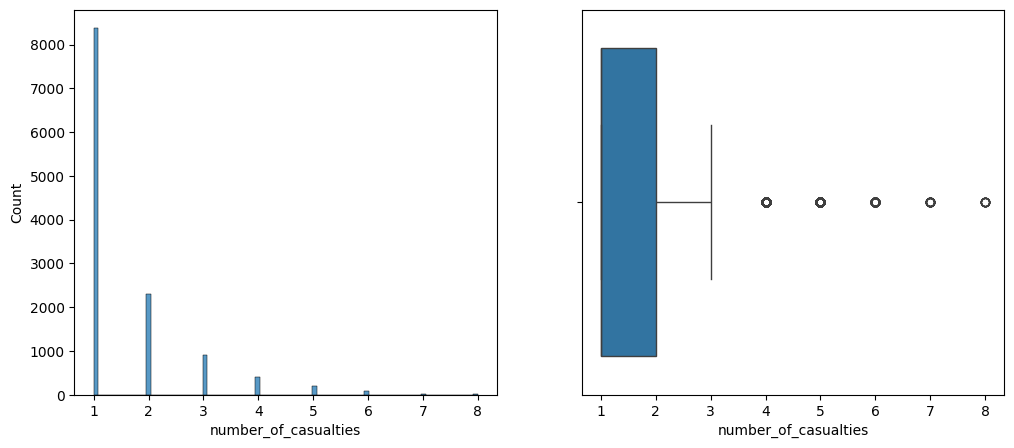

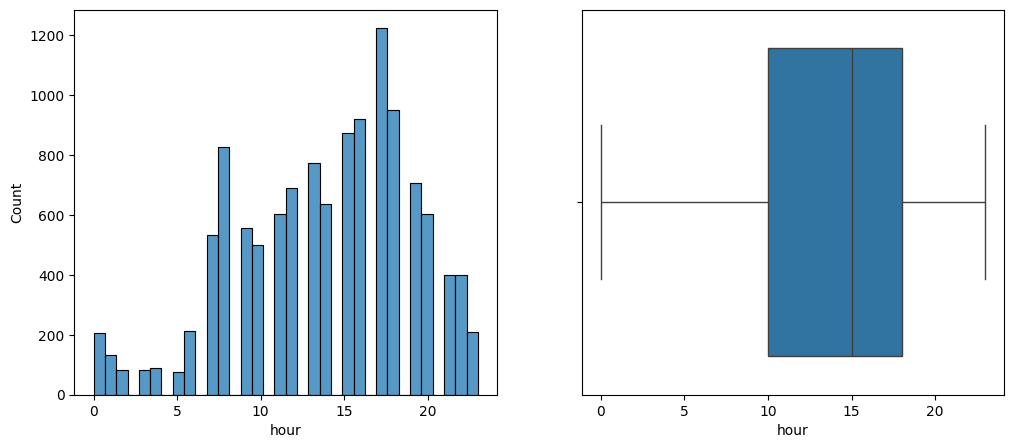

In [40]:
for col in numerical_cols:

    fig,ax=plt.subplots(1,2,figsize=(12,5))

    sns.histplot(
df[col],
ax=ax[0]
)

    sns.boxplot(
x=df[col],
ax=ax[1]
)

    plt.show()

## 19. Key Statistical Findings & Implications

---

### **Key Findings**

*   **1. Casualty counts are positively skewed, with mean exceeding median.**
    *   *Interpretation*: The distribution of `number_of_casualties` is not symmetrical; there's a longer tail towards higher casualty numbers, indicating that while most accidents involve few casualties, some involve significantly more.

*   **2. Median casualty counts suggest most accidents involve low casualties.**
    *   *Interpretation*: The typical accident involves a small number of casualties (often 1 or 2), implying that severe multi-casualty incidents are less frequent but highly impactful.

*   **3. Severe accidents (fatal/serious injury) exhibit higher average casualty counts.**
    *   *Interpretation*: Accidents resulting in fatal or serious injuries tend to involve more people on average compared to slight injuries, as expected.

*   **4. Nighttime and adverse weather conditions show higher mean casualty levels.**
    *   *Interpretation*: Accidents occurring in low light (night) or challenging weather (e.g., raining, snow) are associated with a higher average number of casualties, highlighting increased risk factors under these conditions.

*   **5. Variability in casualty counts indicates the presence of high-impact outlier accidents.**
    *   *Interpretation*: The standard deviation and range confirm that while most accidents have few casualties, there are instances of accidents with significantly higher casualty numbers, which are critical to address for safety improvements.

---

### **Implications**

*   **Targeted Interventions**: Since most accidents have low casualties but severe ones have more, prevention efforts should target factors contributing to high-casualty incidents (e.g., road design, vehicle safety measures).

*   **Resource Allocation**: Emergency services and healthcare providers should be prepared for incidents with varying casualty numbers, particularly for those with higher average casualties during specific conditions (night, adverse weather).

*   **Policy Making**: Traffic safety policies could prioritize reducing factors that increase casualty numbers during high-risk times (night) and conditions (adverse weather).

*   **Driver Training**: Emphasize defensive driving techniques and awareness during adverse conditions and at night, as these correlate with higher casualty rates.

*   **Data-Driven Safety Measures**: Continuous monitoring of casualty distributions can help identify emerging risks and evaluate the effectiveness of safety interventions.